<a href="https://colab.research.google.com/github/tamarakalashnyk20-glitch/python-sales-analysis/blob/main/E_commerce_Sales_%26_Customer_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## E-commerce Sales & Customer Analytics

[Link to the Tableau Executive Sales & Traffic Dashboard](https://public.tableau.com/views/ExecutiveSalesTrafficDashboard/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [ ]:
# Installing a library to work with Google BigQuery
!pip install google-cloud-bigquery pandas pyarrow

# Libraries
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import f_oneway
import statsmodels.api as sm

# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# SQL Query
query = """
SELECT
    s.date as order_date,
    s.ga_session_id as session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium as traffic_source,
    sp.channel as traffic_channel,

    a.id as account_id,
    a.is_verified as email_verified,
    a.is_unsubscribed as unsubscribed,

    p.category,
    p.name as product_name,
    p.price,
    p.short_description as description
FROM `data-analytics-mate.DA.session` s
LEFT JOIN `data-analytics-mate.DA.session_params` sp
ON sp.ga_session_id = s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` a
ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` o
ON o.ga_session_id = s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
ON p.item_id = o.item_id
  """

df = client.query(query).to_dataframe()
df.head()

,order_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,email_verified,unsubscribed,category,product_name,price,description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


## Query Description
order_date - date of order

ga_session_id - session_id, unique identifier for each session

continent - continent where the order was created

country - country where the order was placed

device - device used during the session

browser - browser used during the session

mobile_model_name - mobile device model used during the session

operating_system - operating system of the device

language - language preference of the user/session

medium - (as traffic_source) marketing medium that brought the user (e.g., email, cpc)

channel - (as traffic_channel) marketing channel (e.g., organic, paid, referral)

id - (as account_id) unique account identifier

is_verified - (as email_verified) indicates if the email is verified

is_unsubscribed (as unsubscribed) - indicates if the user unsubscribed from emails

category - product category

name - (as product_name) – name of the product

price - price of the product

short_description - (as description) short description of the product

In [ ]:
# Total number of columns
total_columns = df.shape[1]

# Types of columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
datetime_cols = df.select_dtypes(include='datetime').columns.tolist()
bool_cols = df.select_dtypes(include='bool').columns.tolist()

# Number of unique sessions
unique_sessions = df['ga_session_id'].nunique() if 'ga_session_id' in df.columns else None

# Time period (from… to…)
if 'order_date' in df.columns:
    min_date = df['order_date'].min()
    max_date = df['order_date'].max()
else:
    min_date = max_date = None

# Missing values
missing_values = df.isna().sum()
missing_summary = missing_values[missing_values > 0].sort_values(ascending=False)

# Statistics of numeric columns
df[numeric_cols].describe()



print(f"Total columns: {total_columns}\n")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}\n")
print(f"Datetime columns ({len(datetime_cols)}): {datetime_cols}\n")
print(f"Boolean columns ({len(bool_cols)}): {bool_cols}\n")
print(f"Unique sessions: {unique_sessions}\n")
print(f"Time period: {min_date} to {max_date}\n")
print("Columns with missing values:")
print(missing_summary)
print("\nStatistics of numeric columns:")
print(df[numeric_cols].describe())


Total columns: 18

Numeric columns (5): ['session_id', 'account_id', 'email_verified', 'unsubscribed', 'price']

Categorical columns (12): ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'category', 'product_name', 'description']

Datetime columns (0): []

Boolean columns (0): []

Unique sessions: None

Time period: 2020-11-01 to 2021-01-31

Columns with missing values:
account_id        321600
email_verified    321600
unsubscribed      321600
category          316007
price             316007
product_name      316007
description       316007
language          114266
dtype: int64

Statistics of numeric columns:
              session_id     account_id  email_verified  unsubscribed  \
count           349545.0        27945.0         27945.0       27945.0   
mean   4992250296.631739  659005.065557         0.71698       0.16944   
std    2887450949.537772   13216.529465        0.450474      0.375147   
mi

In [ ]:
# Statistics of numeric columns
df[numeric_cols].describe()

,session_id,account_id,email_verified,unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


In [ ]:
# Most popular categories and their share
for col in categorical_cols:
    print(f"{col} value counts:\n", df[col].value_counts().head(5), "\n")

continent value counts:
 continent
Americas    193179
Asia         83113
Europe       65135
Oceania       3703
Africa        3620
Name: count, dtype: int64 

country value counts:
 country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Name: count, dtype: int64 

device value counts:
 device
desktop    204429
mobile     137267
tablet       7849
Name: count, dtype: int64 

browser value counts:
 browser
Chrome     238460
Safari      83254
<Other>      8930
Edge         8023
Firefox      6433
Name: count, dtype: int64 

mobile_model_name value counts:
 mobile_model_name
Chrome        97254
iPhone        71326
Safari        70891
<Other>       70839
ChromeBook    19084
Name: count, dtype: int64 

operating_system value counts:
 operating_system
Web          203909
Windows       40937
iOS           40102
Android       29808
Macintosh     26116
Name: count, dtype: int64 

language value counts:
 language
en-us    

In [ ]:
# Finding dublicates
missing_percent = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent)

unsubscribed         92.005321
email_verified       92.005321
account_id           92.005321
description          90.405241
product_name         90.405241
category             90.405241
price                90.405241
language             32.689925
session_id            0.000000
order_date            0.000000
traffic_source        0.000000
operating_system      0.000000
mobile_model_name     0.000000
browser               0.000000
country               0.000000
device                0.000000
continent             0.000000
traffic_channel       0.000000
dtype: float64


##**Comprehensive Sales and User Behavior Analysis**

In [ ]:

# Which continents (top 3) and countries (top 5) generate the highest sales and the largest number of orders for our company?
top3_continents_sales = (
    df.groupby("continent")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
)
top5_countries_sales = (
    df.groupby("country")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)
top3_continents_orders = (
    df.groupby("continent")["session_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(3)
)

# Top 10 product categories by total sales amount
top10_categories_sales = (
    df.groupby("category")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Find the top 10 product categories in the country with the highest sales. Is the situation different from the overall results?
top_country = df.groupby("country")["price"].sum().idxmax()
print(f"Country with highest total sales: {top_country}\n")

top10_categories_top_country = (
    df[df["country"] == top_country]  # Filter the data by country
      .groupby("category")["price"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)


# Analyze sales by device types and models (as a % of total sales).

total_sales = df["price"].sum()
device_sales_pct = df.groupby("device")["price"].sum() / total_sales * 100
device_sales_pct = device_sales_pct.sort_values(ascending=False)

mobile_sales_pct = (
    df[df["device"] == "Mobile"]
      .groupby("mobile_model_name")["price"]
      .sum() / total_sales * 100
) #filtering only mobile device
mobile_sales_pct = mobile_sales_pct.sort_values(ascending=False)

# Analyze sales by traffic sources (as a % of total sales).
total_sales = df["price"].sum()
traffic_sales_pct = df.groupby("traffic_source")["price"].sum() / total_sales * 100
traffic_sales_pct = traffic_sales_pct.sort_values(ascending=False)

# What percentage of registered users have confirmed their email address?
total_users = df["account_id"].nunique()
verified_users = df[df["email_verified"] == True]["account_id"].nunique() # total number of email verified users
verified_pct = verified_users / total_users * 100 #percenage


# What percentage of registered users have unsubscribed from the mailing list?
total_users = df["account_id"].nunique()
unsubscribed_users = df[df["unsubscribed"] == True]["account_id"].nunique() #total number of unsubscribed users
unsubscribed_pct = unsubscribed_users / total_users * 100

# Is there a difference in purchasing behavior between users who have unsubscribed from the mailing list and those who are still subscribed?
sales_by_user_status = (
    df.groupby(["unsubscribed", "account_id"])["price"]
      .sum()
      .reset_index()
) #Group the data by subscription status and user

summary_sales_by_status = sales_by_user_status.groupby("unsubscribed")["price"].agg(
    total_sales="sum",
    avg_sales_per_user="mean",
    median_sales_per_user="median",
    user_count="count"
).reset_index() #Groub by unsubscribed status

summary_sales_by_status["status"] = summary_sales_by_status["unsubscribed"].map({True: "Unsubscribed", False: "Subscribed"})

# In which countries are the largest numbers of registered users located?
users_by_country = df.groupby("country")["account_id"].nunique().sort_values(ascending=False) #number of unique users
top10_countries_users = users_by_country.head(10)

# Sales distribution by browser (percentage of total sales).
total_sales = df["price"].sum()
sales_by_browser_pct = df.groupby("browser")["price"].sum() / total_sales * 100
sales_by_browser_pct = sales_by_browser_pct.sort_values(ascending=False)

#Which product categories generate the highest sales per user?
sales_per_user_by_category = (
    df.groupby("category").agg(
        total_sales=("price", "sum"),
        unique_users=("account_id", "nunique")
    )
)
sales_per_user_by_category["sales_per_user"] = sales_per_user_by_category["total_sales"] / sales_per_user_by_category["unique_users"]
top10_categories_sales_per_user = sales_per_user_by_category.sort_values("sales_per_user", ascending=False).head(10)

#Which countries generate the highest sales per user?
sales_per_user_by_country = (
    df.groupby("country").agg(
        total_sales=("price", "sum"),
        unique_users=("account_id", "nunique")
    )
)
sales_per_user_by_country["sales_per_user"] = sales_per_user_by_country["total_sales"] / sales_per_user_by_country["unique_users"]
top10_countries_sales_per_user = sales_per_user_by_country.sort_values("sales_per_user", ascending=False).head(10)


print(f"Top-3 continents by sales:\n{top3_continents_sales}\n")
print(f"Top-5 countries by sales:\n{top5_countries_sales}\n")
print(f"Top-5 continents by orders:\n{top3_continents_orders}\n")
print(f"Top-10 product categories by total sales amount:\n{top10_categories_sales}\n")
print(f"Top-10 product categories in {top_country} by total sales:\n{top10_categories_top_country}\n")
print("Sales by device type (% of total sales):\n", device_sales_pct, "\n")
print("Top-10 mobile models by sales (% of total sales):\n", mobile_sales_pct.head(10))
print("Sales by traffic source (% of total sales):\n", traffic_sales_pct, "\n")
print(f"Percentage of registered users who verified their email: {verified_pct:.2f}%")
print(f"Percentage of registered users who unsubscribed: {unsubscribed_pct:.2f}%")
print(summary_sales_by_status[["status", "user_count", "total_sales", "avg_sales_per_user", "median_sales_per_user"]])
print("Top-10 countries by number of registered users:\n", top10_countries_users)
print("Sales by browser (% of total):\n", sales_by_browser_pct)
print("Top-10 categories by sales per user:\n", top10_categories_sales_per_user[["sales_per_user"]])
print("Top-10 countries by sales per user:\n", top10_countries_sales_per_user[["sales_per_user"]])

Country with highest total sales: United States

Top-3 continents by sales:
continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64

Top-5 countries by sales:
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64

Top-5 continents by orders:
continent
Americas    193179
Asia         83113
Europe       65135
Name: session_id, dtype: int64

Top-10 product categories by total sales amount:
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children'

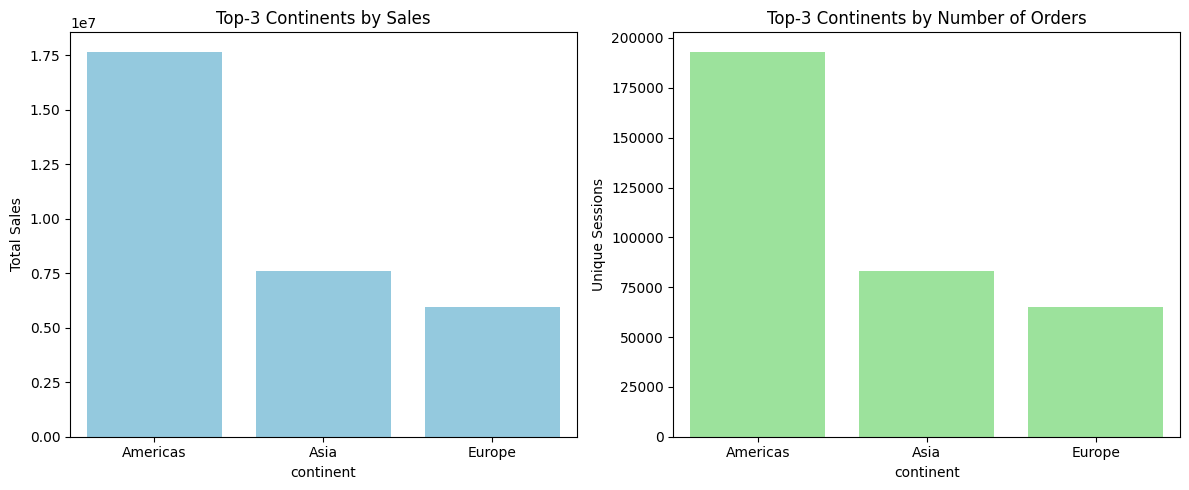

In [ ]:
# Top 3 continents by sales and orders
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(x=top3_continents_sales.index, y=top3_continents_sales.values, color="skyblue", ax=axes[0])
axes[0].set_title("Top-3 Continents by Sales")
axes[0].set_ylabel("Total Sales")

sns.barplot(x=top3_continents_orders.index, y=top3_continents_orders.values, color="lightgreen", ax=axes[1])
axes[1].set_title("Top-3 Continents by Number of Orders")
axes[1].set_ylabel("Unique Sessions")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1087/2657282834.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


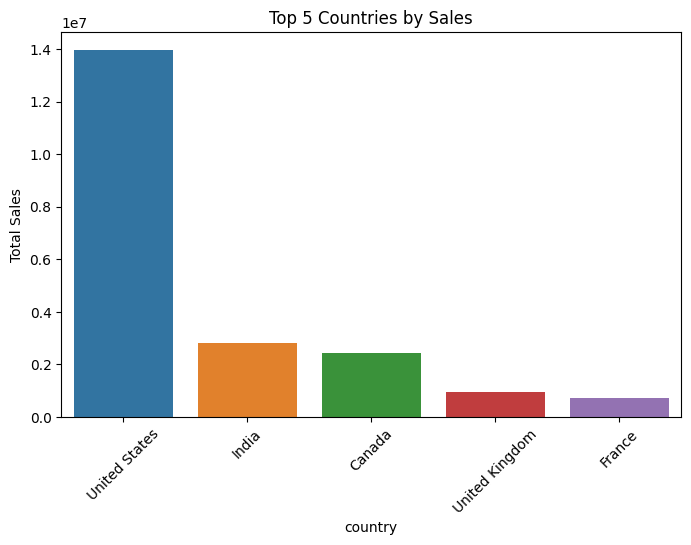

In [ ]:
#Top 5 countries by sales
plt.figure(figsize=(8,5))

# Define 5 colors for the 5 bars
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

sns.barplot(
    x=top5_countries_sales.index,
    y=top5_countries_sales.values,
    palette=colors  # now each bar has its own color
)

plt.title("Top 5 Countries by Sales")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1087/182444253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_browser_pct.index, y=sales_by_browser_pct.values, palette="cool")


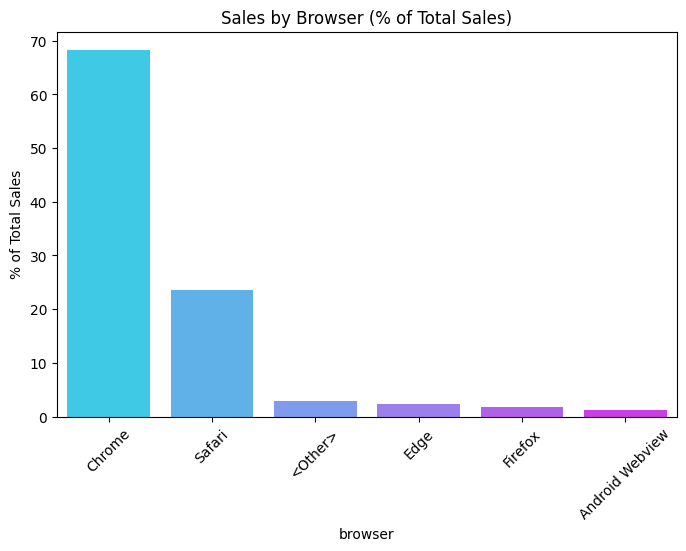

In [ ]:
#Sales by browser
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_browser_pct.index, y=sales_by_browser_pct.values, palette="cool")
plt.title("Sales by Browser (% of Total Sales)")
plt.ylabel("% of Total Sales")
plt.xticks(rotation=45)
plt.show()

##**Pivot tables**

In [ ]:
#Pivot table for the number of sessions by channel and mobile device type
pivot_sessions = pd.pivot_table(
    df,
    values="session_id",
    index="traffic_channel",
    columns="device",
    aggfunc="nunique"
)


#Pivot table for sales by categories and country
top5_countries = df.groupby("country")["price"].sum().nlargest(5).index #Top-5 country by sales
top10_categories = df.groupby("category")["price"].sum().nlargest(10).index #Top-10 category by price
filtered_df = df[
    (df["country"].isin(top5_countries)) &
    (df["category"].isin(top10_categories))
] #Filtering
pivot_sales = pd.pivot_table(
    filtered_df,
    values="price",
    index="category",
    columns="country",
    aggfunc="sum"
)


#Pivot table for sales and number of users by country
pivot_country_acc_price = pd.pivot_table(
    df,
    values=["price", "account_id"],
    index="country",
    aggfunc={
        "price": "sum",
        "account_id": "nunique"
    }
)

#Pivot table for average sales by country and traffic channel
pivot_avg_sales = pd.pivot_table(
    df,
    values="price",
    index="country",
    columns="traffic_channel",
    aggfunc="mean"
)


#Pivot table foor sales by operating system and device
pivot_sales_os = pd.pivot_table(
    df,
    values="price",
    index="operating_system",
    columns="device",
    aggfunc="sum"
)



print("Pivot table for the number of sessions by channel and mobile device type\n")
print(pivot_sessions)
print("Pivot table: Top-10 categories sales in Top-5 countries\n")
print(pivot_sales)
print("Pivot table for sales and number of users by country\n")
print(pivot_country_acc_price)
print("Average sales by country and traffic channel:\n")
print(pivot_avg_sales)
print("Sales by operating system and device:\n")
print(pivot_sales_os)

Pivot table for the number of sessions by channel and mobile device type

device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638
Undefined          12527    8486     470
Pivot table: Top-10 categories sales in Top-5 countries

country                             Canada    France     India  \
category                                                         
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0  

##**Sales trend analysis**

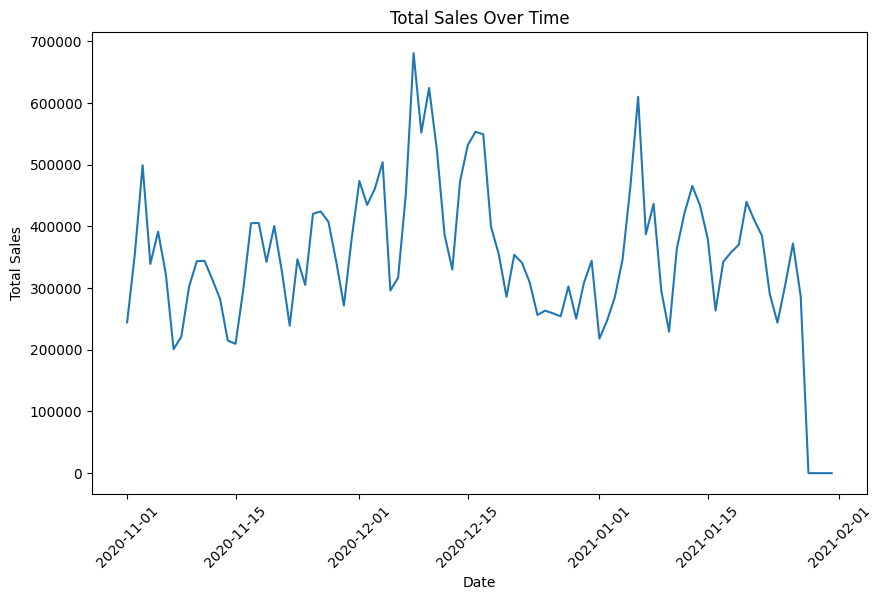

In [ ]:
#Total sales over time
sales_by_date = df.groupby("order_date")["price"].sum().sort_index()
plt.figure(figsize=(10,6))
plt.plot(sales_by_date.index, sales_by_date.values)

plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

The chart shows regular cycles, with small rises and falls approximately every 7 days, which may indicate weekly seasonality (for example, weekends or email campaigns on specific days of the week affecting sales). Additionally, there is a large peak in December, likely due to the holiday season and promotions, typically associated with Black Friday and Christmas.

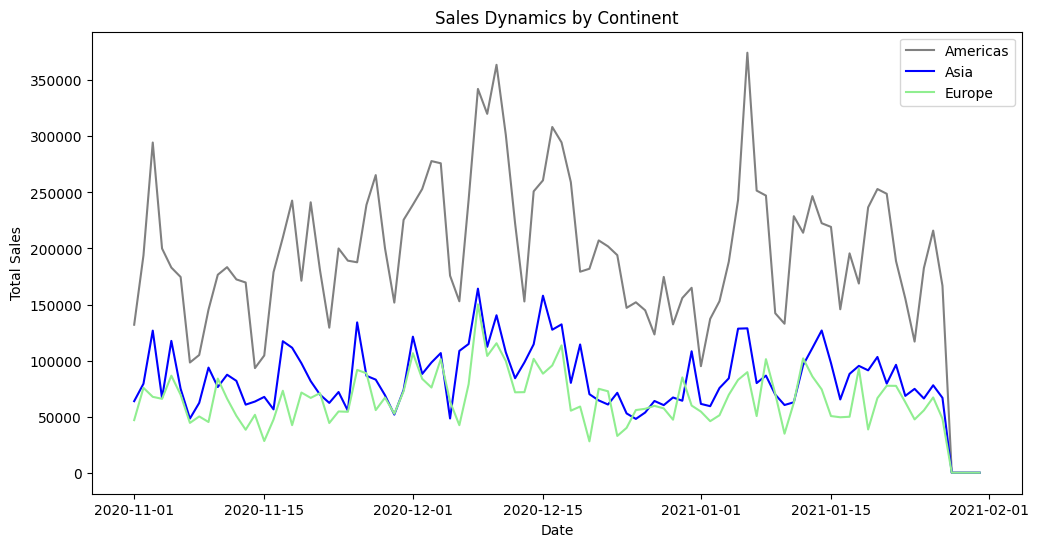

In [ ]:
# Sales Dynamics by Continent
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Filtering continens
continents = ["Americas", "Asia", "Europe"]
df_filtered = df[df["continent"].isin(continents)]

# Group by continent
sales_continent = df_filtered.groupby(["order_date", "continent"])["price"].sum().unstack()
plt.figure(figsize=(12,6))

colors = {"Americas": "grey", "Asia": "blue", "Europe": "lightgreen"}

for continent in continents:
    plt.plot(sales_continent.index, sales_continent[continent], label=continent, color=colors[continent])

plt.title("Sales Dynamics by Continent")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.show()

The Americas lead in total sales, showing sharp fluctuations and a pronounced holiday peak in December. Asia and Europe have lower sales with smoother dynamics and less prominent December peaks. All continents exhibit a weekly sales cycle.

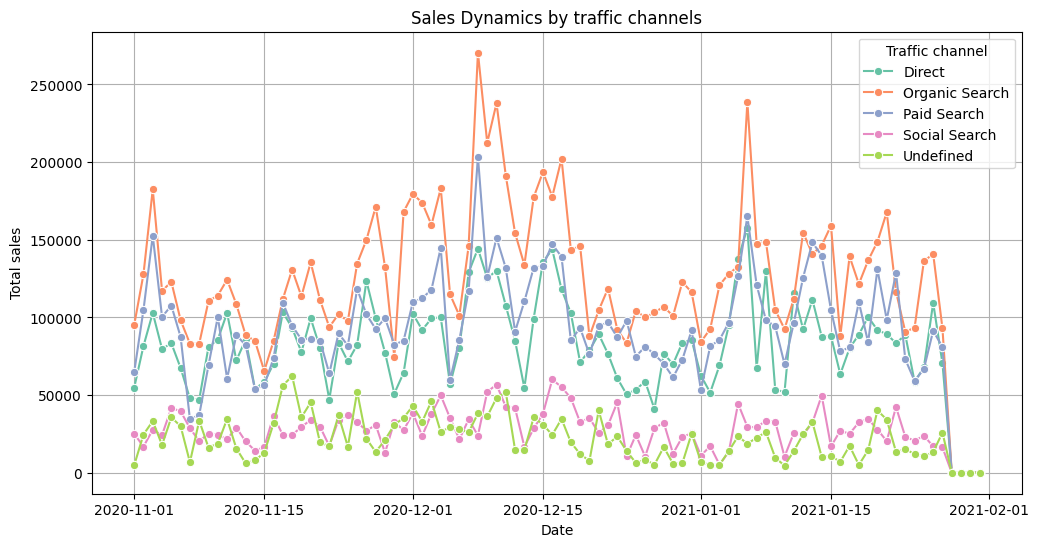

In [ ]:
# Sales Dynamics by traffic channels
sales_per_channel = df.groupby(['order_date', 'traffic_channel'])['price'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(
    data=sales_per_channel,
    x='order_date',
    y='price',
    hue='traffic_channel',  # різні кольори для каналів
    marker='o',
    palette='Set2'
)
plt.title('Sales Dynamics by traffic channels')
plt.xlabel('Date')
plt.ylabel('Total sales')
plt.grid(True)
plt.legend(title='Traffic channel')
plt.show()

Organic Search consistently drives the highest sales, showing clear peaks in mid-December and early January. Paid Search and Direct channels follow with moderate fluctuations. Social Search and Undefined channels contribute the least. Overall, sales exhibit regular ups and downs, likely reflecting weekends and holiday periods

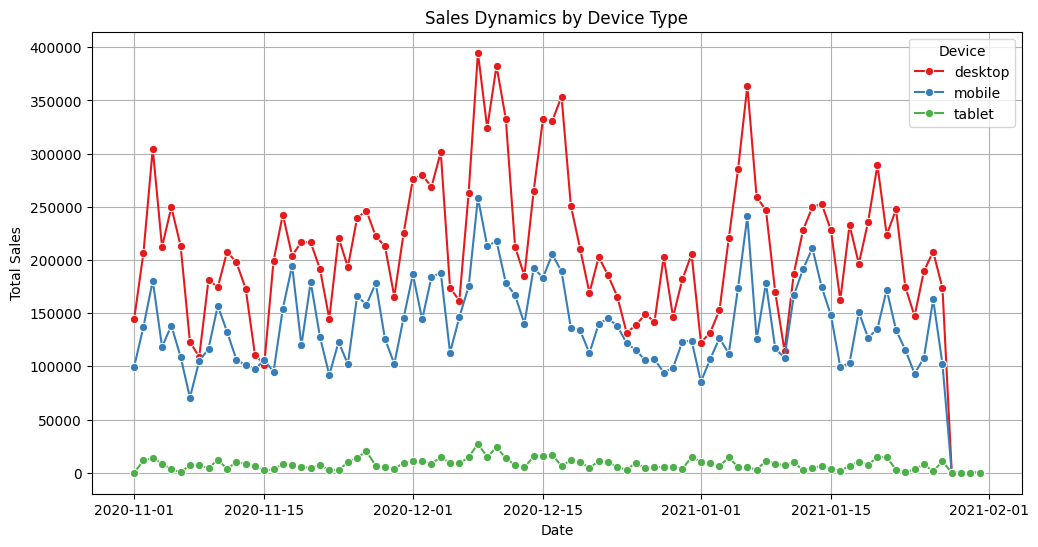

In [ ]:
# Sales Dynamics by device type
df['order_date'] = pd.to_datetime(df['order_date'])
sales_per_device = df.groupby(['order_date', 'device'])['price'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(
    data=sales_per_device,
    x='order_date',
    y='price',
    hue='device',  # різні кольори для девайсів
    marker='o',
    palette='Set1'
)
plt.title('Sales Dynamics by Device Type')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.legend(title='Device')
plt.show()

The chart reveals that desktop users are the primary revenue driver, consistently outperforming mobile and tablet segments. Sales across all devices show significant volatility with a clear peak during the first half of December, likely due to holiday promotions or seasonal shopping. While desktop and mobile trends are highly correlated—often rising and falling in tandem—the tablet segment remains negligible and flat throughout the entire period. Notably, there is a sharp, total drop-off in sales for all categories at the end of January, suggesting either a data reporting cutoff or a complete cessation of operations.

##**Statistical Analysis of Relationships**

In [ ]:
#
df['order_date'] = pd.to_datetime(df['order_date'])
daily_stats = df.groupby('order_date').agg(
    sessions=('session_id', 'nunique'),
    sales=('price', 'sum')
).reset_index()

daily_stats.head()

,order_date,sessions,sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


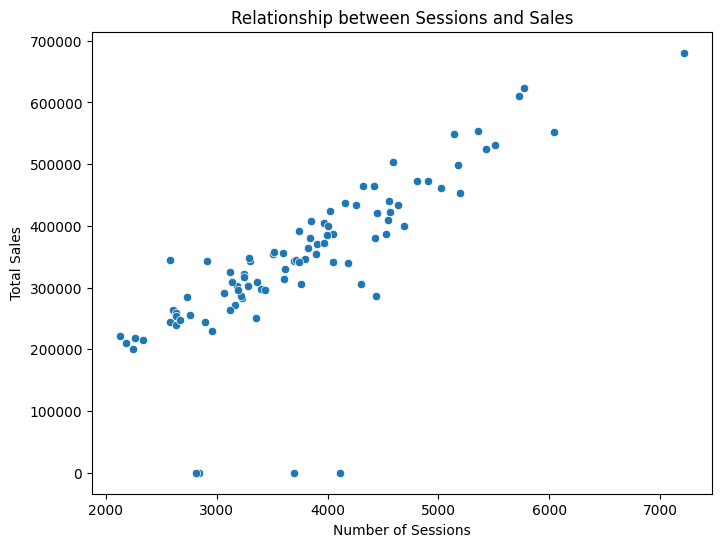

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=daily_stats, x='sessions', y='sales')

plt.title('Relationship between Sessions and Sales')
plt.xlabel('Number of Sessions')
plt.ylabel('Total Sales')

plt.show()

In [ ]:
corr, p_value = pearsonr(daily_stats['sessions'], daily_stats['sales'])

print("Pearson correlation:", corr)
print("p-value:", p_value)

Pearson correlation: 0.7910809164540891
p-value: 6.483532312080735e-21


The relationship between the number of sessions and total daily sales was analyzed. The Pearson correlation coefficient equals 0.79, which indicates a strong positive correlation between these metrics. This means that as the number of sessions increases, total sales tend to increase as well.

The p-value (6.48 × 10⁻²¹) is significantly lower than the standard significance level of 0.05, indicating that the observed correlation is statistically significant. Therefore, we can conclude that there is a reliable positive relationship between website traffic (sessions) and sales.

In [ ]:
top_continents = (
    df.groupby('continent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)
df['order_date'] = pd.to_datetime(df['order_date'])

continent_sales = (
    df[df['continent'].isin(top_continents)]
    .groupby(['order_date', 'continent'])['price']
    .sum()
    .unstack()
)

continent_sales.head()

continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


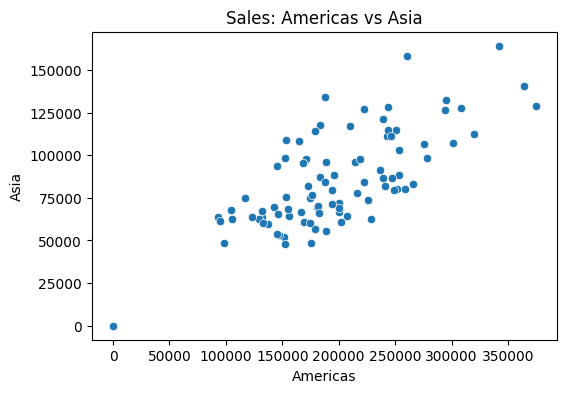

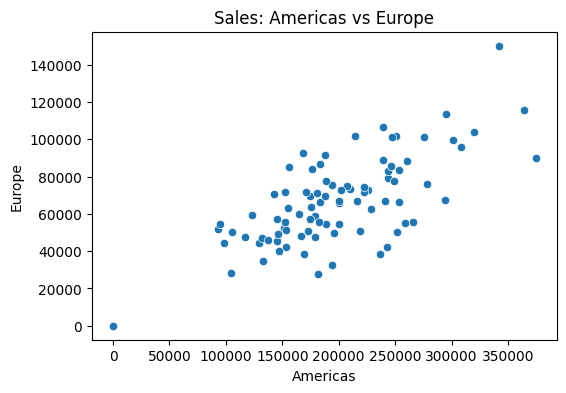

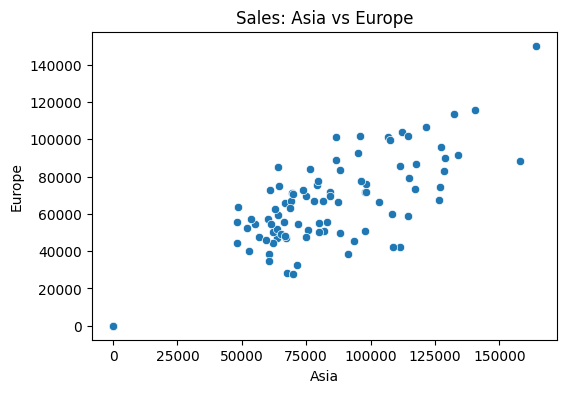

In [ ]:
import itertools

continents = continent_sales.columns

for c1, c2 in itertools.combinations(continents, 2):

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=continent_sales[c1], y=continent_sales[c2])

    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f'Sales: {c1} vs {c2}')

    plt.show()

In [ ]:
continents = continent_sales.columns

for c1, c2 in itertools.combinations(continents, 2):
    corr, p = pearsonr(continent_sales[c1], continent_sales[c2])
    print(f"{c1} vs {c2}")
    print("Correlation:", corr)
    print("p-value:", p)
    print()

Americas vs Asia
Correlation: 0.7920245629479414
p-value: 5.409189396197475e-21

Americas vs Europe
Correlation: 0.7705864582886499
p-value: 2.6714492240629956e-19

Asia vs Europe
Correlation: 0.7684273823164164
p-value: 3.8649460090531196e-19



The relationship between sales across the top three continents (Americas, Asia, and Europe) was analyzed using Pearson correlation.

The results show a strong positive correlation between sales in all pairs of continents:

Americas vs Asia: r = 0.79

Americas vs Europe: r = 0.77

Asia vs Europe: r = 0.77

All p-values are extremely small (p < 0.05), which means that the correlations are statistically significant.

This indicates that sales trends across these continents tend to move in the same direction. When sales increase in one region, they also tend to increase in the others. This may suggest the presence of global demand patterns, common marketing campaigns, or seasonal effects influencing multiple regions simultaneously.

In [ ]:
top_channels = (
    df.groupby('traffic_channel')['price']
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)
channel_sales = (
    df[df['traffic_channel'].isin(top_channels)]
    .groupby(['order_date', 'traffic_channel'])['price']
    .sum()
    .unstack()
)

channel_sales.head()

traffic_channel,Direct,Organic Search,Paid Search
order_date,,,
2020-11-01,54669.5,95112.0,64688.0
2020-11-02,81561.5,127746.5,104780.8
2020-11-03,102909.5,182521.9,152641.3
2020-11-04,79683.6,117067.1,100332.0
2020-11-05,83367.6,122938.4,107648.0


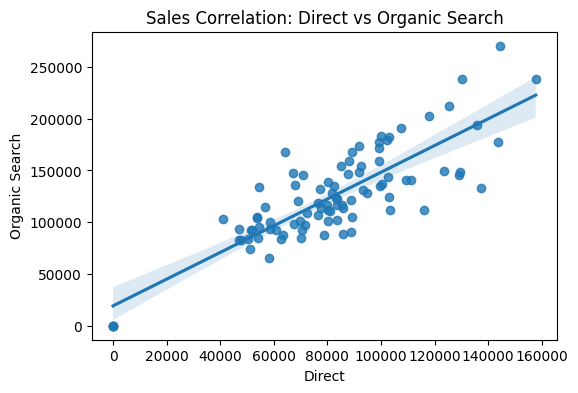

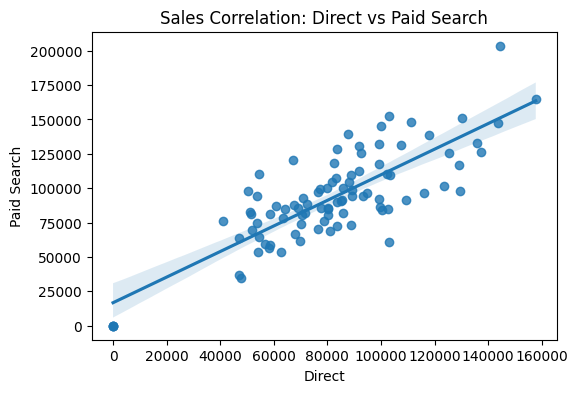

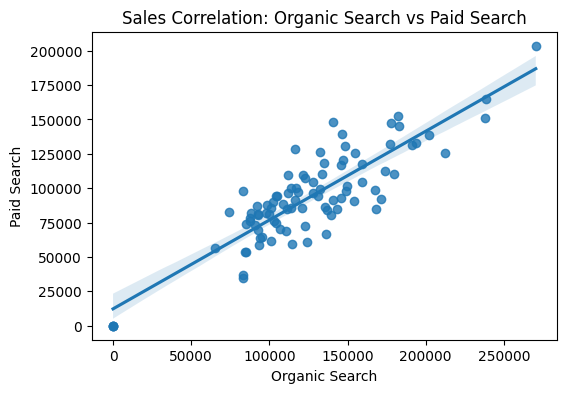

In [ ]:
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
channels = channel_sales.columns

for c1, c2 in itertools.combinations(channels, 2):

    plt.figure(figsize=(6,4))
    sns.regplot(x=channel_sales[c1], y=channel_sales[c2])

    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f'Sales Correlation: {c1} vs {c2}')

    plt.show()

In [ ]:

for c1, c2 in itertools.combinations(channels, 2):

    corr, p = spearmanr(channel_sales[c1], channel_sales[c2])

    print(f"{c1} vs {c2}")
    print("Spearman correlation:", corr)
    print("p-value:", p)
    print()

Direct vs Organic Search
Spearman correlation: 0.7796633681679461
p-value: 5.405253983075643e-20

Direct vs Paid Search
Spearman correlation: 0.729368969450353
p-value: 1.65402161751709e-16

Organic Search vs Paid Search
Spearman correlation: 0.7933814235950555
p-value: 4.16183654939949e-21



The relationship between sales from the top traffic channels (Direct, Organic Search, and Paid Search) was analyzed using Spearman correlation.

The results indicate a strong positive correlation between all pairs of channels:

Direct vs Organic Search: r = 0.78, p < 0.0001

Direct vs Paid Search: r = 0.73, p < 0.0001

Organic Search vs Paid Search: r = 0.79, p < 0.0001

All p-values are extremely small, indicating that these correlations are statistically significant.

This means that when sales increase in one channel, they tend to increase in the others as well. Such patterns may reflect overall traffic trends, marketing campaigns, or seasonal effects that affect multiple channels simultaneously.

In [ ]:
top_categories = (
    df.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
category_sales = (
    df[df['category'].isin(top_categories)]
    .groupby(['order_date', 'category'])['price']
    .sum()
    .unstack()
)

category_sales.head()

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
order_date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [ ]:
categories = category_sales.columns

for c1, c2 in itertools.combinations(categories, 2):
    corr, p = spearmanr(category_sales[c1], category_sales[c2])
    print(f"{c1} vs {c2}")
    print("Spearman correlation:", corr)
    print("p-value:", p)
    print()

Beds vs Bookcases & shelving units
Spearman correlation: 0.5427424183720194
p-value: 4.690831718453576e-08

Beds vs Cabinets & cupboards
Spearman correlation: 0.4403684266140679
p-value: 1.7587830397743514e-05

Beds vs Chairs
Spearman correlation: 0.5349406502060513
p-value: 7.913415552119658e-08

Beds vs Sofas & armchairs
Spearman correlation: 0.521714627875031
p-value: 1.864367723360297e-07

Bookcases & shelving units vs Cabinets & cupboards
Spearman correlation: 0.5287062801592055
p-value: 1.1906129581027331e-07

Bookcases & shelving units vs Chairs
Spearman correlation: 0.6367510830897116
p-value: 2.5854375788053062e-11

Bookcases & shelving units vs Sofas & armchairs
Spearman correlation: 0.6256031841076398
p-value: 7.188990897333014e-11

Cabinets & cupboards vs Chairs
Spearman correlation: 0.5268218801732945
p-value: 1.3449152556100263e-07

Cabinets & cupboards vs Sofas & armchairs
Spearman correlation: 0.6312035504209081
p-value: 4.322908272307604e-11

Chairs vs Sofas & armchair

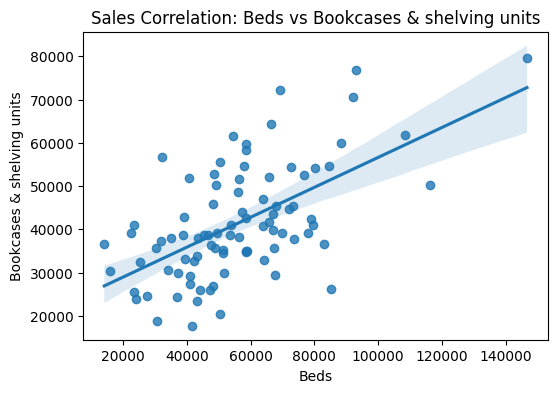

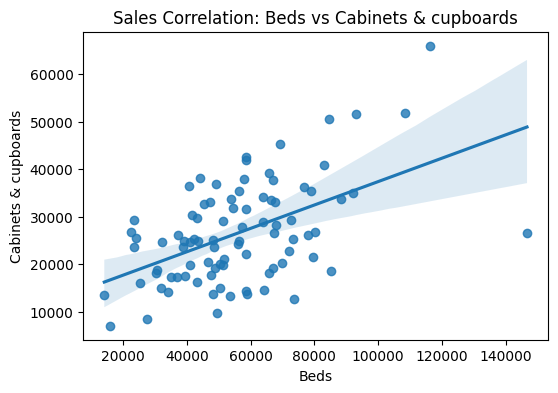

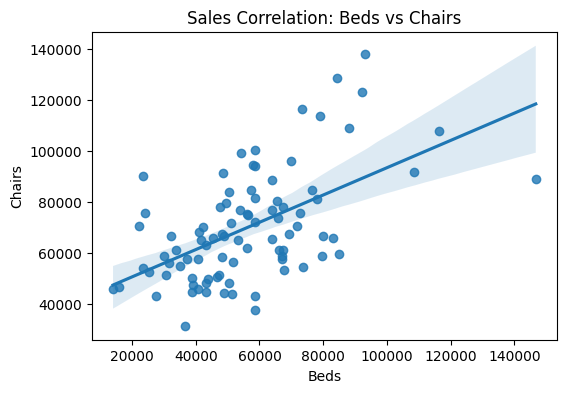

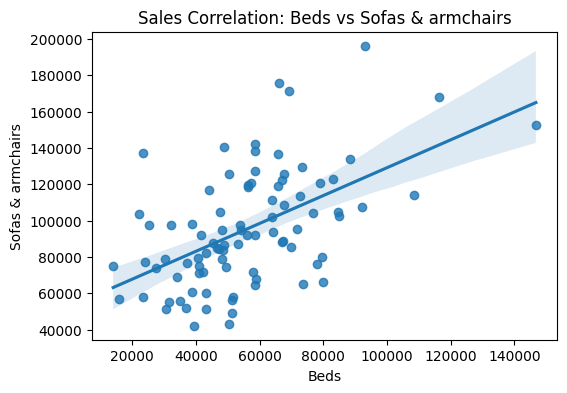

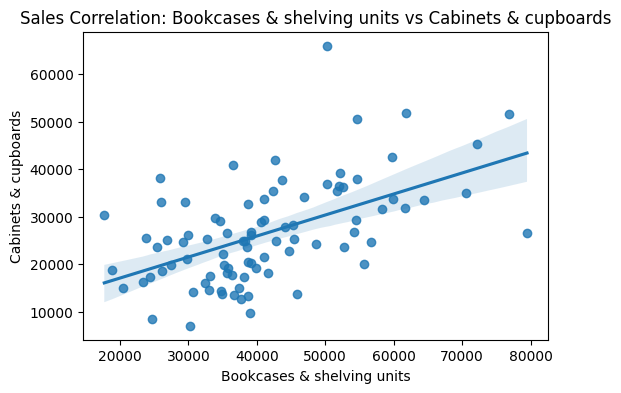

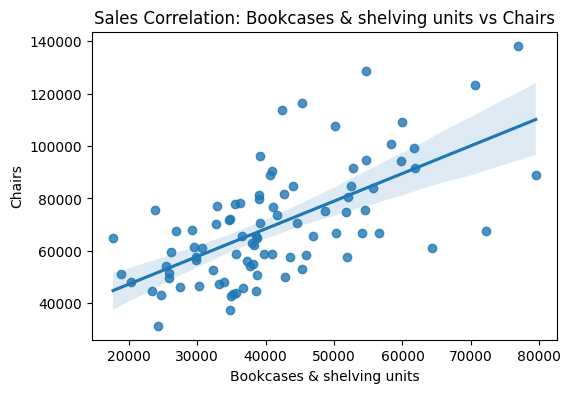

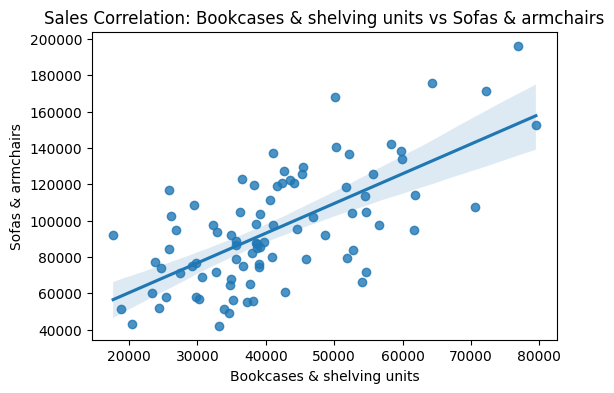

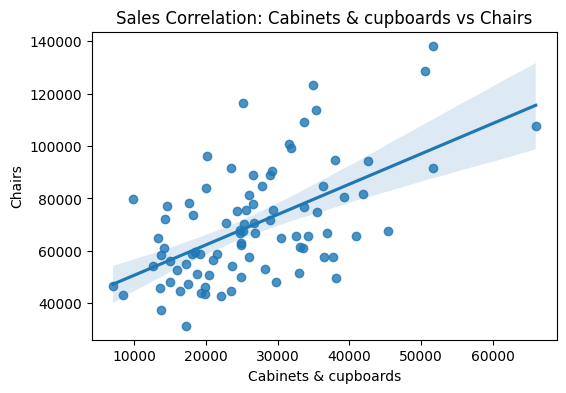

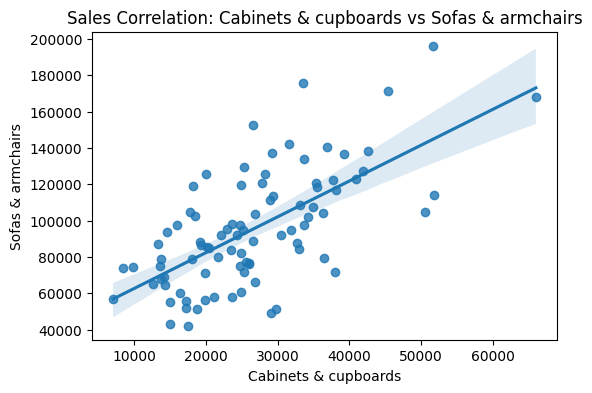

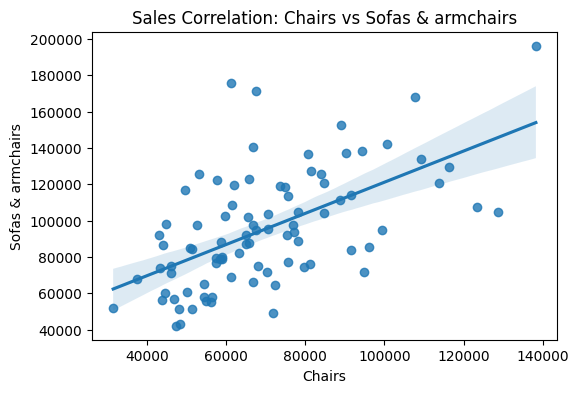

In [ ]:
for c1, c2 in itertools.combinations(categories, 2):
    plt.figure(figsize=(6,4))
    sns.regplot(x=category_sales[c1], y=category_sales[c2])
    plt.xlabel(c1)
    plt.ylabel(c2)
    plt.title(f'Sales Correlation: {c1} vs {c2}')
    plt.show()

The relationship between sales of the top 5 product categories (Beds, Bookcases & Shelving Units, Cabinets & Cupboards, Chairs, Sofas & Armchairs) was analyzed using Spearman correlation.

The results indicate moderate to strong positive correlations between all category pairs:

Beds vs Bookcases & Shelving Units: r = 0.54, p < 0.0001

Beds vs Cabinets & Cupboards: r = 0.44, p < 0.0001

Beds vs Chairs: r = 0.53, p < 0.0001

Beds vs Sofas & Armchairs: r = 0.52, p < 0.0001

Bookcases & Shelving Units vs Cabinets & Cupboards: r = 0.53, p < 0.0001

Bookcases & Shelving Units vs Chairs: r = 0.64, p < 0.0001

Bookcases & Shelving Units vs Sofas & Armchairs: r = 0.63, p < 0.0001

Cabinets & Cupboards vs Chairs: r = 0.53, p < 0.0001

Cabinets & Cupboards vs Sofas & Armchairs: r = 0.63, p < 0.0001

Chairs vs Sofas & Armchairs: r = 0.58, p < 0.0001

All p-values are extremely small, indicating that these correlations are statistically significant.

This suggests that sales trends across these product categories tend to move together: when sales increase in one category, sales in related categories also tend to rise. Such patterns may reflect cross-category demand, seasonal effects, or combined marketing strategies.


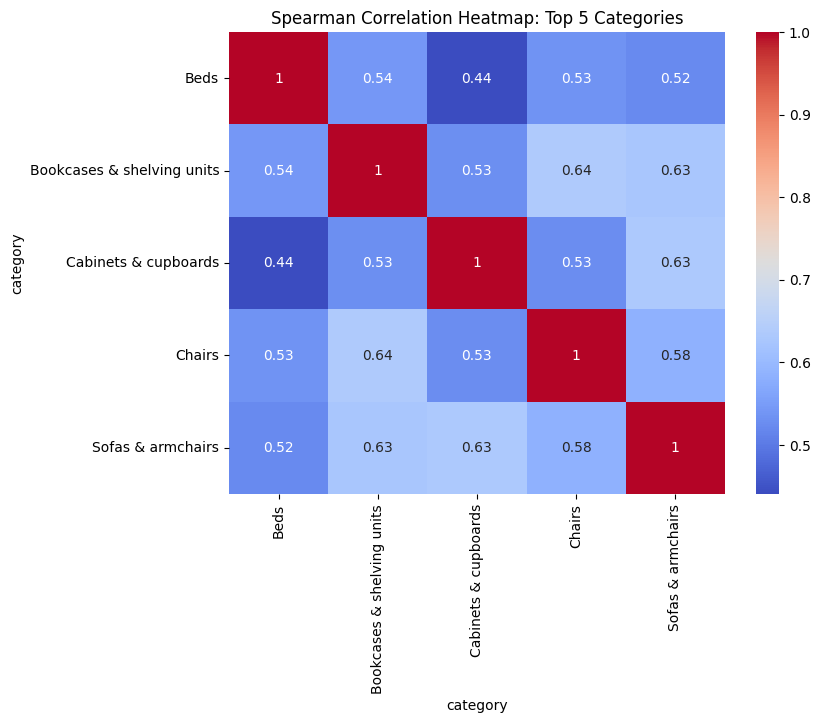

In [ ]:
#Visualizing Strong Correlations Between Categories
plt.figure(figsize=(8,6))
sns.heatmap(category_sales.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap: Top 5 Categories")
plt.show()

This heatmap visualizes the strength of the relationship between sales volumes across the top 5 furniture categories.

Key Takeaways:
Positive Trend: All categories show a moderate positive correlation (ranging from 0.44 to 0.64), suggesting that sales trends across these categories generally move in the same direction.

Strongest Correlation (0.64): Found between "Chairs" and "Bookcases & shelving units." This implies that customers purchasing home office or library storage are likely to buy seating simultaneously.

Living Room Synergy: "Sofas & armchairs" correlate strongly with both bookcases and cabinets (0.63), indicating a synchronized demand for living area furnishings.

Lowest Correlation (0.44): Observed between "Beds" and "Cabinets & cupboards," likely because these items serve distinct rooms (bedroom vs. utility/storage areas) and may follow different replacement cycles.